In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### **Step 1: Load the dataset and explore the feature space.**

In [ ]:
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

df['label_num'] = df.label.map({'ham':0, 'spam':1})

print("Dataset Preview:")
display(df.head())
print(f"\nClass Distribution:\n{df.label.value_counts()}")

Dataset Preview:


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0



Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


### **Step 2: Scale the numeric features to avoid distance bias.**

In [ ]:
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
X = tfidf.fit_transform(df['message']).toarray()
y = df['label_num'].values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")

Features scaled successfully.


### **Step 3 & 4: Train Classifiers (1-NN, 3-NN, 5-NN, and 7-NN) and Compare Metrics**

In [ ]:
results = []
ks = [1, 3, 5, 7]
metrics = ['euclidean', 'manhattan']

for k in ks:
    for metric in metrics:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train_scaled, y_train)
        y_pred = knn.predict(X_test_scaled)

        acc = accuracy_score(y_test, y_pred)
        results.append({
            'K': k,
            'Metric': metric,
            'Accuracy': acc
        })

results_df = pd.DataFrame(results)
display(results_df.pivot(index='K', columns='Metric', values='Accuracy'))

Metric,euclidean,manhattan
K,,
1,0.966816,0.973991
3,0.962332,0.944395
5,0.955157,0.930045
7,0.952466,0.930045


### **Step 5. Plot Decision Boundaries**

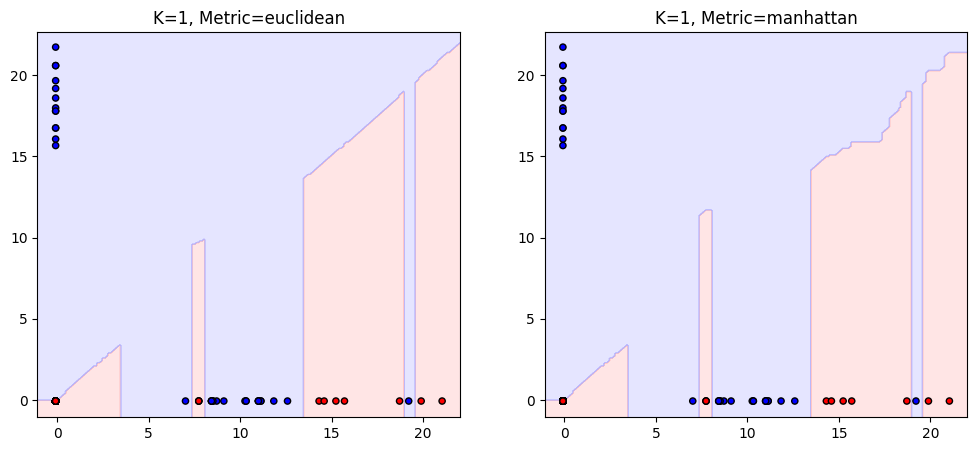

In [ ]:
X_vis = X_train_scaled[:, [10, 20]]
y_vis = y_train

def plot_decision_boundary(k, metric):
    clf = KNeighborsClassifier(n_neighbors=k, metric=metric)
    clf.fit(X_vis, y_vis)

    x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
    y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
    plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, s=20, edgecolor='k', cmap=ListedColormap(['#FF0000', '#0000FF']))
    plt.title(f"K={k}, Metric={metric}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plot_decision_boundary(1, 'euclidean')
plt.subplot(1, 2, 2); plot_decision_boundary(1, 'manhattan')
plt.show()

### **Step 6: Detailed Evaluation**

Confusion Matrix:


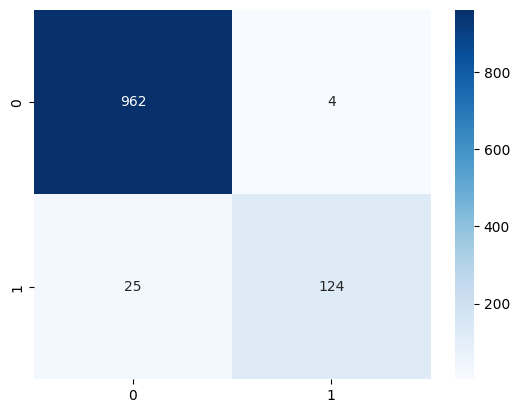


Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       0.97      0.83      0.90       149

    accuracy                           0.97      1115
   macro avg       0.97      0.91      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [ ]:
best_knn = KNeighborsClassifier(n_neighbors=1, metric='manhattan')
best_knn.fit(X_train_scaled, y_train)
y_pred = best_knn.predict(X_test_scaled)

print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

### **Step 7: Discussion: Why Normalization Matters**
In K-NN, the distance between data points determines the class. If one feature has a range of 0-1000 and another 0-1, the distance will be dominated by the larger feature. **Standardization (Scaling)** ensures all features are on the same scale, allowing the model to learn from the patterns rather than the magnitudes.

### **Stap 8: Comparison Table and Final Report**

In [ ]:
comparison_report = results_df.sort_values(by='Accuracy', ascending=False)

print("K-NN Performance Comparison Table:")
display(comparison_report)

best_row = comparison_report.iloc[0]
print(f"\nBest Model Summary:")
print(f"- K Value: {best_row['K']}")
print(f"- Distance Metric: {best_row['Metric']}")
print(f"- Accuracy: {best_row['Accuracy']:.4f}")

K-NN Performance Comparison Table:


,K,Metric,Accuracy
1,1,manhattan,0.973991
0,1,euclidean,0.966816
2,3,euclidean,0.962332
4,5,euclidean,0.955157
6,7,euclidean,0.952466
3,3,manhattan,0.944395
5,5,manhattan,0.930045
7,7,manhattan,0.930045



Best Model Summary:
- K Value: 1
- Distance Metric: manhattan
- Accuracy: 0.9740
